<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB11(9).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 9

In [ ]:
!pip install kaggle -q

In [ ]:
from google.colab import files

# Upload your kaggle.json token file
print("Upload your kaggle.json file:")
files.upload()

# Set up Kaggle credentials
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download chest X-ray dataset (~2GB)
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip
print("Dataset ready!")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:21<00:00, 113MB/s]

Dataset ready!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

TRAIN_DIR = "chest_xray/train"
TEST_DIR  = "chest_xray/test"
IMG_SIZE  = (224, 224)   # VGG16 expects 224x224
BATCH     = 32

In [ ]:
# Data generators with augmentation for training
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary'   # NORMAL vs PNEUMONIA
)
test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary'
)

print("Classes:", train_data.class_indices)
# {'NORMAL': 0, 'PNEUMONIA': 1}

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


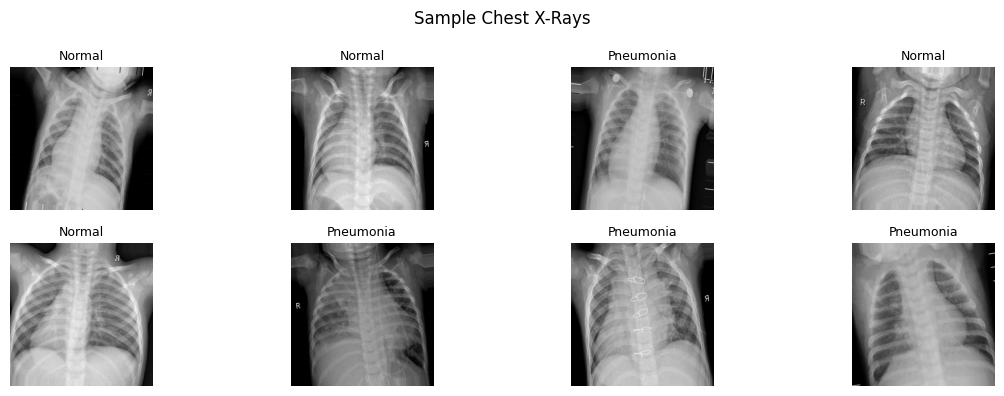

In [ ]:
images, labels = next(train_data)
label_names = ['Normal', 'Pneumonia']

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(label_names[int(labels[i])], fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Chest X-Rays", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
def build_scratch_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                      input_shape=(224, 224, 3), padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')   # binary output
    ])
    return model

scratch_model = build_scratch_model()
scratch_model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
scratch_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training from SCRATCH...")
scratch_history = scratch_model.fit(
    train_data,
    epochs=10,
    validation_data=test_data,
    verbose=1
)

Training from SCRATCH...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 667ms/step - accuracy: 0.8167 - loss: 0.3916 - val_accuracy: 0.8061 - val_loss: 0.5385
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 642ms/step - accuracy: 0.9179 - loss: 0.2089 - val_accuracy: 0.8093 - val_loss: 0.6000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 674ms/step - accuracy: 0.9304 - loss: 0.1766 - val_accuracy: 0.7516 - val_loss: 0.9756
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 643ms/step - accuracy: 0.9268 - loss: 0.1938 - val_accuracy: 0.7885 - val_loss: 0.8430
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.9350 - loss: 0.1691 - val_accuracy: 0.8157 - val_loss: 0.4638
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 642ms/step - accuracy: 0.9408 - loss: 0.1580 - val_accuracy: 0.8077 - val_loss: 0.5478
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 630ms/step - accuracy: 0.9440 - loss: 0.1463 - val_accuracy: 0.7853 - val_loss: 1.0143
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 632ms/

In [ ]:
def build_transfer_model():
    # Load VGG16 pretrained on ImageNet, remove top classifier
    base_model = VGG16(weights='imagenet',
                       include_top=False,
                       input_shape=(224, 224, 3))

    # FREEZE all VGG16 layers — don't retrain them
    base_model.trainable = False

    # Add our own classifier on top
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

transfer_model = build_transfer_model()
transfer_model.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])
transfer_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
print("Training with TRANSFER LEARNING (VGG16)...")
transfer_history = transfer_model.fit(
    train_data,
    epochs=10,
    validation_data=test_data,
    verbose=1
)

Training with TRANSFER LEARNING (VGG16)...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 730ms/step - accuracy: 0.8261 - loss: 0.3856 - val_accuracy: 0.8317 - val_loss: 0.3897
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 684ms/step - accuracy: 0.9122 - loss: 0.2264 - val_accuracy: 0.8365 - val_loss: 0.4003
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 687ms/step - accuracy: 0.9252 - loss: 0.1972 - val_accuracy: 0.8606 - val_loss: 0.3489
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 685ms/step - accuracy: 0.9296 - loss: 0.1760 - val_accuracy: 0.8846 - val_loss: 0.2825
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 685ms/step - accuracy: 0.9388 - loss: 0.1627 - val_accuracy: 0.8782 - val_loss: 0.3336
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 687ms/step - accuracy: 0.9375 - loss: 0.1632 - val_accuracy: 0.8349 - val_loss: 0.4396
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 684ms/step - accuracy: 0.9417 - loss: 0.1497 - val_accuracy: 0.8846 - val_loss: 0.3464
Epoch 8/10
163/163 ━━━━━━━━━━━━━━

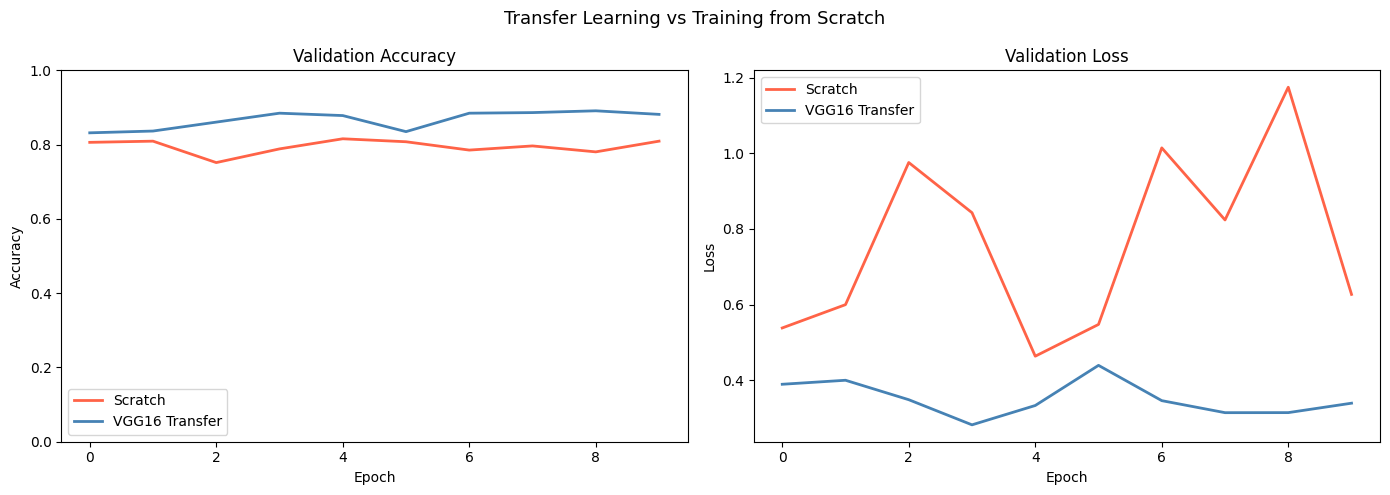

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(scratch_history.history['val_accuracy'],
             label='Scratch', color='tomato', linewidth=2)
axes[0].plot(transfer_history.history['val_accuracy'],
             label='VGG16 Transfer', color='steelblue', linewidth=2)
axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[0].set_ylim([0, 1])

# Loss comparison
axes[1].plot(scratch_history.history['val_loss'],
             label='Scratch', color='tomato', linewidth=2)
axes[1].plot(transfer_history.history['val_loss'],
             label='VGG16 Transfer', color='steelblue', linewidth=2)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend()

plt.suptitle('Transfer Learning vs Training from Scratch', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
_, scratch_acc  = scratch_model.evaluate(test_data,  verbose=0)
_, transfer_acc = transfer_model.evaluate(test_data, verbose=0)

print("="*40)
print(f"Scratch model accuracy  : {scratch_acc:.2%}")
print(f"Transfer learning acc   : {transfer_acc:.2%}")
print(f"Improvement             : +{(transfer_acc - scratch_acc):.2%}")
print("="*40)

Scratch model accuracy  : 80.93%
Transfer learning acc   : 88.14%
Improvement             : +7.21%


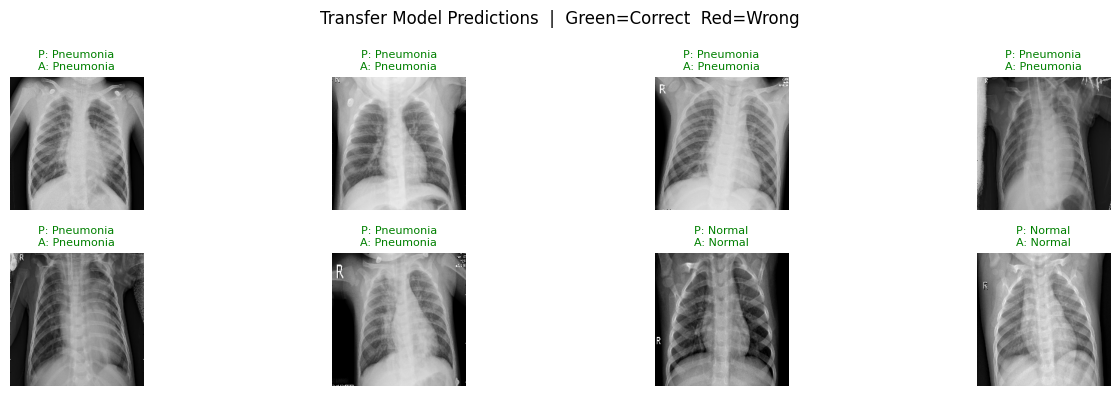

In [ ]:
test_images, test_labels = next(test_data)
preds = transfer_model.predict(test_images[:8], verbose=0)

plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(test_images[i])
    pred   = "Pneumonia" if preds[i] > 0.5 else "Normal"
    actual = "Pneumonia" if test_labels[i] == 1 else "Normal"
    color  = 'green' if pred == actual else 'red'
    plt.title(f"P: {pred}\nA: {actual}", fontsize=8, color=color)
    plt.axis('off')
plt.suptitle("Transfer Model Predictions  |  Green=Correct  Red=Wrong")
plt.tight_layout(); plt.show()